In [18]:
import pandas as pd 
import numpy as np 
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
files = sorted(Path("Data").glob("CRMLSSold2025*.csv"))
dfs = []
for f in files:
    df = pd.read_csv(f)
    df["source_file"] = f.name
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

/var/folders/wx/bwm3xtjn1td5nh5v6xgwj7m80000gn/T/ipykernel_15602/1882464853.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f)


In [5]:
print(df.head())

           BuyerAgentAOR           ListAgentAOR                Flooring  \
0      PasadenaFoothills      PasadenaFoothills                     NaN   
1  BeverlyHillsGreaterLa  BeverlyHillsGreaterLa  Carpet,Stone,Tile,Wood   
2            PalmSprings            PalmSprings                    Tile   
3             HighDesert             HighDesert                     NaN   
4            PalmSprings            PalmSprings             Carpet,Tile   

  ViewYN WaterfrontYN BasementYN PoolPrivateYN  OriginalListPrice  ListingKey  \
0   True          NaN        NaN           NaN           699000.0   538489291   
1   True          NaN       True          True            45000.0   509724017   
2   True          NaN        NaN          True             8500.0   498101084   
3   True          NaN        NaN           NaN           100000.0   446933645   
4   True          NaN        NaN          True             7500.0   441682993   

                   ListAgentEmail  ... NewConstructionYN  Gara

In [7]:
df.shape

(260104, 81)

In [13]:
df.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [24]:
exp_df = df[(df['PropertyType']=='Residential') & 
            (df['PropertySubType']=='SingleFamilyResidence')]
exp_df = exp_df[["ClosePrice", "LivingArea", "BedroomsTotal", 
                 "BathroomsTotalInteger", "LotSizeSquareFeet"]]
#drop missing values for now
exp_df = exp_df.dropna()

In [25]:
print(exp_df.head())    

    ClosePrice  LivingArea  BedroomsTotal  BathroomsTotalInteger  \
11    530000.0      1656.0            4.0                    2.0   
12    700000.0      1558.0            4.0                    2.0   
14   1195000.0      2695.0            3.0                    3.0   
17    454500.0      1110.0            3.0                    2.0   
18    690000.0      1431.0            3.0                    2.0   

    LotSizeSquareFeet  
11            13800.0  
12             3000.0  
14            11761.0  
17             6872.0  
18             6975.0  


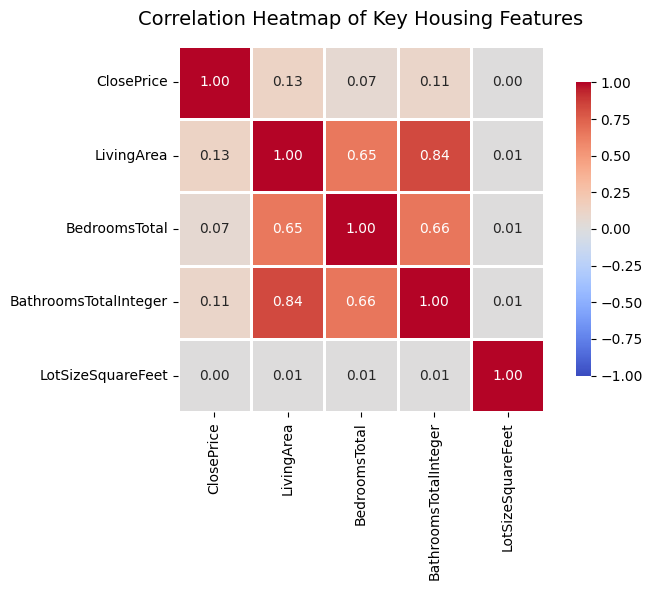

In [26]:
plt.figure(figsize=(8, 6))
corr_matrix = exp_df.corr()


sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.8,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap of Key Housing Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Mean Close Price ($, Log Scale)')

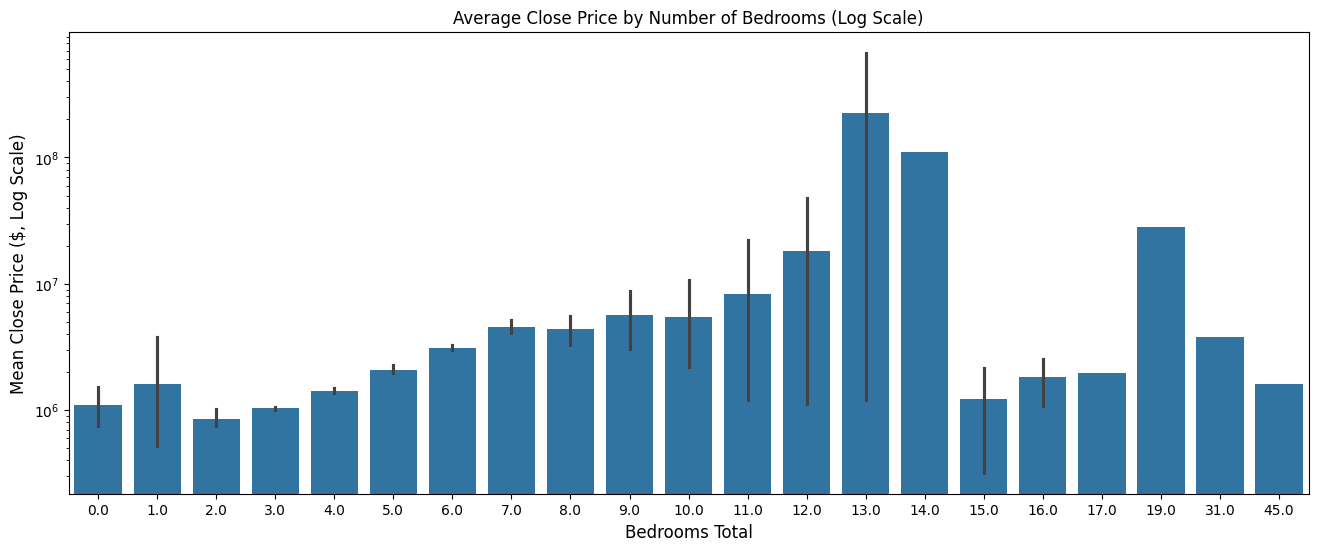

In [28]:
fig, ax1 = plt.subplots(1, 1, figsize=(16, 6))

sns.barplot(
    x="BedroomsTotal",
    y="ClosePrice",
    data=exp_df,
    ax=ax1,
)

# Crucial step: Make the y-axis logarithmic
ax1.set_yscale("log")

ax1.set_title("Average Close Price by Number of Bedrooms (Log Scale)")
ax1.set_xlabel("Bedrooms Total", fontsize=12)
ax1.set_ylabel("Mean Close Price ($, Log Scale)", fontsize=12)

We can see that for properties with bedrooms numbers like 13 the variance is very high that means that there are a very few properties with 13 bedrooms to be extremely high. Also, a single family home having 13+ bedrooms is unlikely so maybe we consider 7+ bedrooms

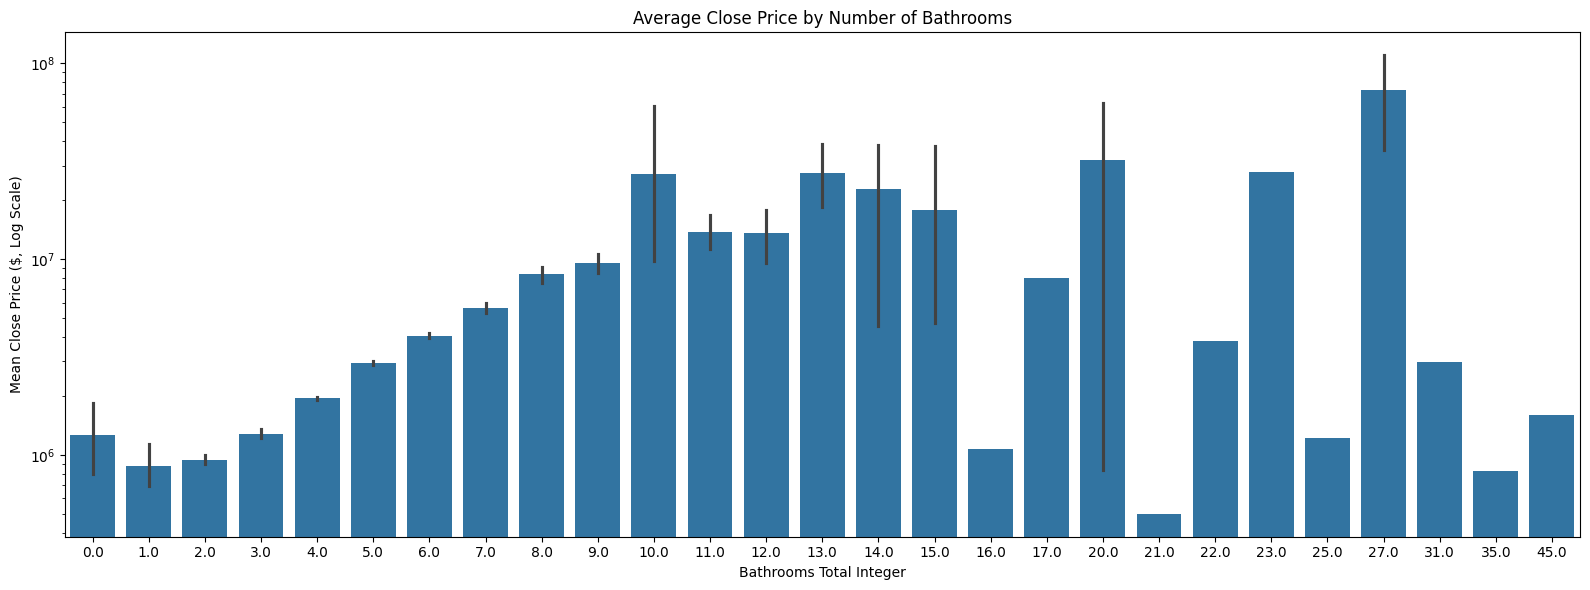

In [29]:
fig, ax2 = plt.subplots(1, 1, figsize=(16, 6))

sns.barplot(
    x="BathroomsTotalInteger",
    y="ClosePrice",
    data=exp_df,
    ax=ax2,
)

ax2.set_yscale("log")
ax2.set_title("Average Close Price by Number of Bathrooms")
ax2.set_xlabel("Bathrooms Total Integer")
ax2.set_ylabel("Mean Close Price ($, Log Scale)")

plt.tight_layout()
plt.show()

For the bathrooms too, we have a good chart from 0-9 bathrooms. As soon as the number of bathrooms increase, the price increases which makes sense. After 9 bathrooms, we can see that the variance is becoming too high for impractical bathroom numbers like 27 or 10 which maybe present in mansions or very large houses

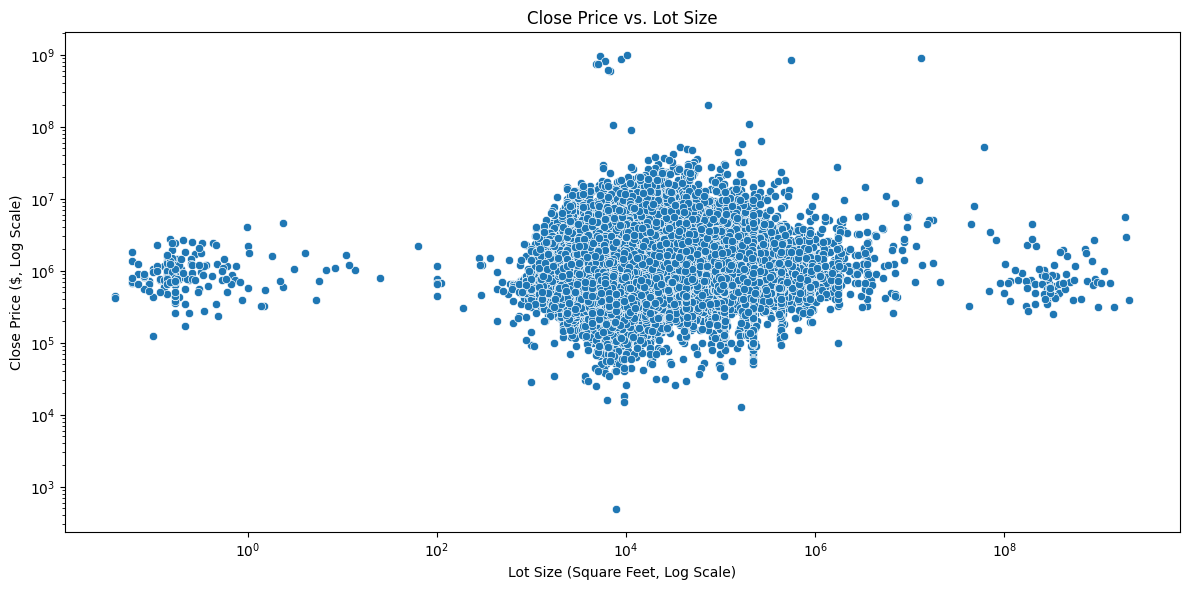

In [31]:
fig, ax3 = plt.subplots(1, 1, figsize=(12, 6))

sns.scatterplot(x="LotSizeSquareFeet", y="ClosePrice", data=exp_df, ax=ax3)


ax3.set_yscale("log")
ax3.set_xscale("log")  #

ax3.set_title("Close Price vs. Lot Size")
ax3.set_xlabel("Lot Size (Square Feet, Log Scale)")
ax3.set_ylabel("Close Price ($, Log Scale)")

plt.tight_layout()
plt.show()

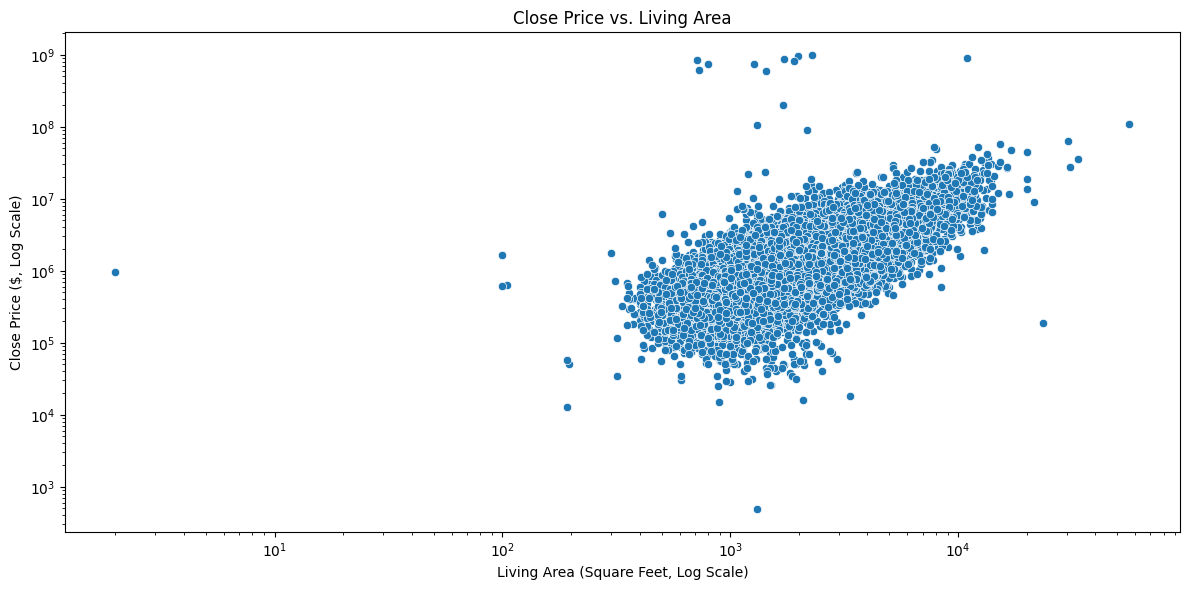

In [33]:
fig, ax4 = plt.subplots(1, 1, figsize=(12, 6))

sns.scatterplot(x="LivingArea", y="ClosePrice", data=exp_df, ax=ax4)


ax4.set_yscale("log")
ax4.set_xscale("log")  #

ax4.set_title("Close Price vs. Living Area")
ax4.set_xlabel("Living Area (Square Feet, Log Scale)")
ax4.set_ylabel("Close Price ($, Log Scale)")

plt.tight_layout()
plt.show()